In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Pokemon.csv")

df.head()


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [3]:
df.shape

(800, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [5]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [6]:
df.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [7]:
df["Type 2"].fillna("None", inplace=True)

In [8]:
df.isnull().sum()

#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

In [9]:
X = df[
    [
        "HP",
        "Attack",
        "Defense",
        "Sp. Atk",
        "Sp. Def",
        "Speed"
    ]
]

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

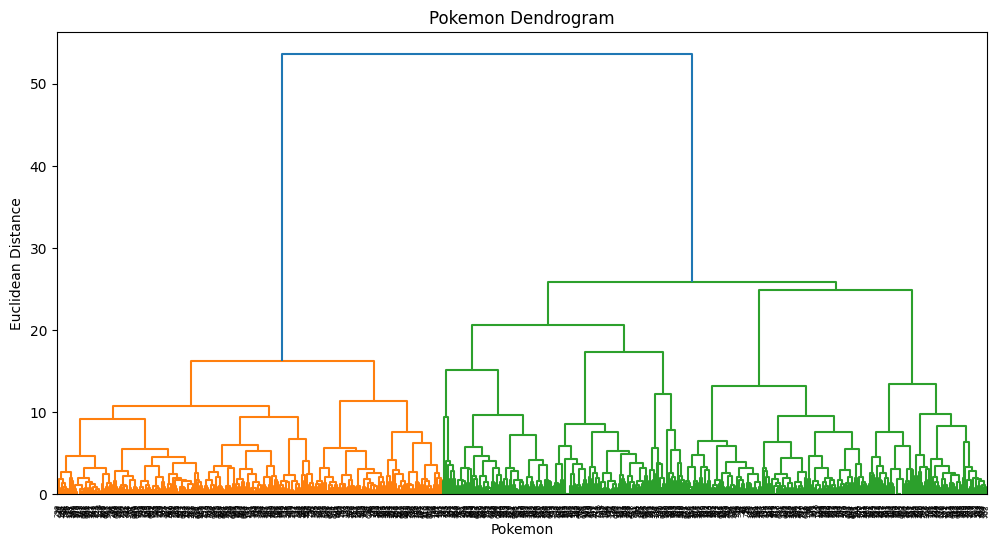

In [11]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(
        X_scaled,
        method="ward"
    )
)

plt.title("Pokemon Dendrogram")
plt.xlabel("Pokemon")
plt.ylabel("Euclidean Distance")

plt.show()

In [12]:
hc = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",
    linkage="ward"
)

clusters = hc.fit_predict(X_scaled)

In [13]:
df["Cluster"] = clusters

df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,1
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,1
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0
4,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,False,1


In [14]:
df["Cluster"].value_counts()

Cluster
1    332
0    209
3    157
2    102
Name: count, dtype: int64

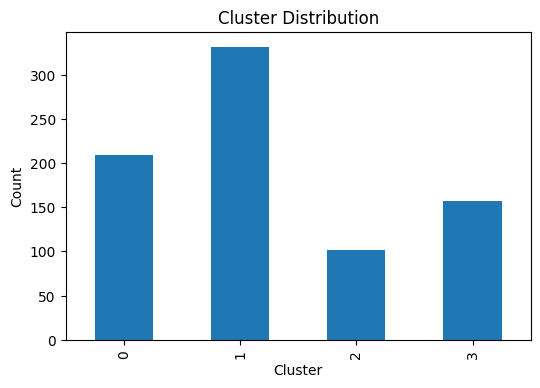

In [15]:
plt.figure(figsize=(6,4))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("Cluster Distribution")

plt.show()

In [16]:
cluster_summary = df.groupby("Cluster")[
    [
        "HP",
        "Attack",
        "Defense",
        "Sp. Atk",
        "Sp. Def",
        "Speed"
    ]
].mean()

cluster_summary

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Cluster,,,,,,
0,88.578947,88.004785,96.827751,82.933014,91.043062,59.492823
1,52.346386,56.939759,56.572289,50.948795,52.981928,49.605422
2,89.696078,120.843137,91.137255,120.558824,92.176471,102.686275
3,66.025478,86.484076,68.528662,74.592357,73.261146,97.101911


In [17]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

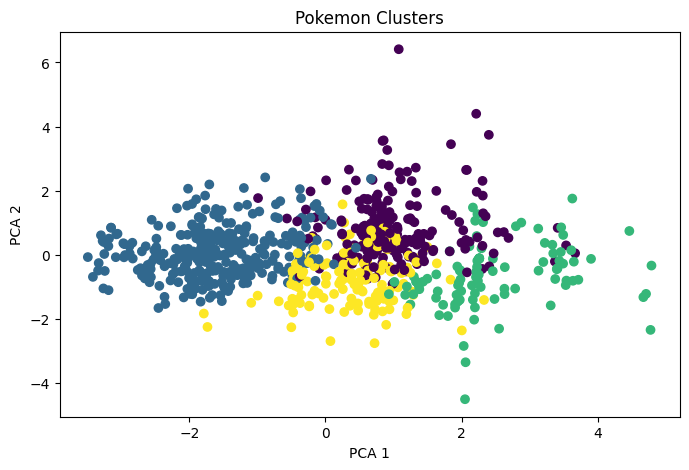

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df["Cluster"]
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Pokemon Clusters")

plt.show()

In [19]:
cluster_summary

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Cluster,,,,,,
0,88.578947,88.004785,96.827751,82.933014,91.043062,59.492823
1,52.346386,56.939759,56.572289,50.948795,52.981928,49.605422
2,89.696078,120.843137,91.137255,120.558824,92.176471,102.686275
3,66.025478,86.484076,68.528662,74.592357,73.261146,97.101911


In [20]:
cluster_names = {
    0: "Balanced Pokemon",
    1: "Defensive Pokemon",
    2: "Fast Offensive Pokemon",
    3: "Elite Powerful Pokemon"
}

In [21]:
df["Cluster_Name"] = df["Cluster"].map(
    cluster_names
)

In [22]:
df.to_csv(
    "clustered_pokemon.csv",
    index=False
)

In [23]:
import pickle

pickle.dump(
    scaler,
    open("scaler.pkl", "wb")
)